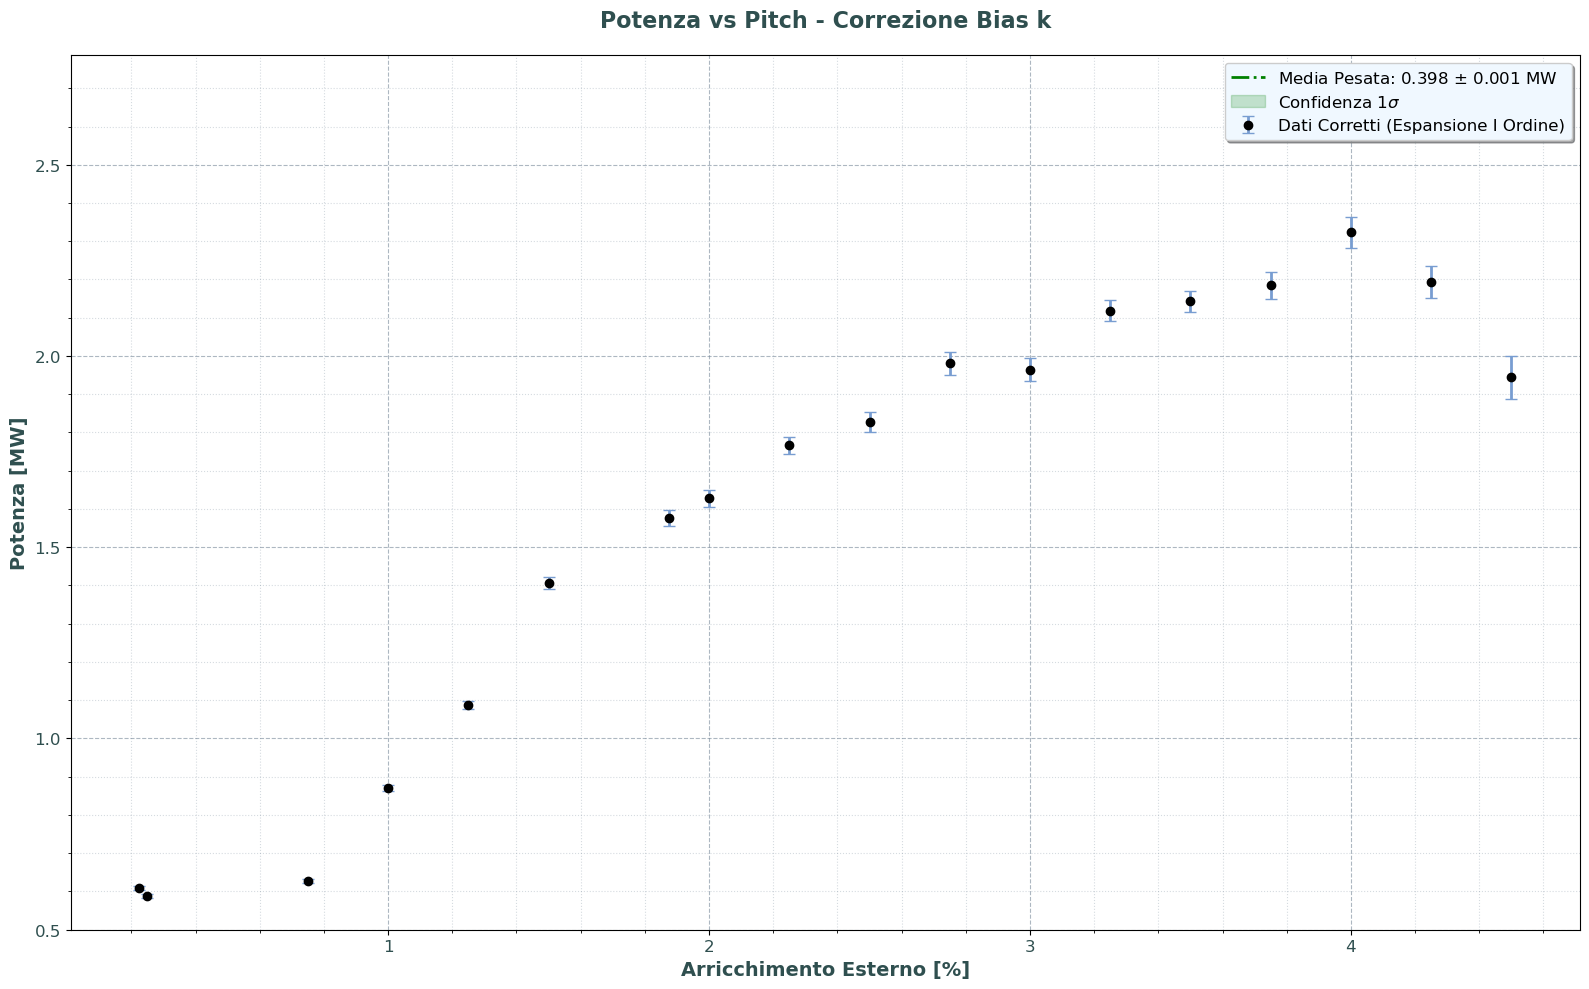

In [1]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import openmc

# Costanti Fisiche
E_FISSION_J = 200.0 * 1e6 * 1.6022e-19
S_INTENSITY = 2.02e17

def parse_result_final(filename):
    data = []
    with open(filename, 'r') as file:
        for line in file:
            line = line.strip()
            if not line or line.startswith('-') or line.startswith('=') or 'Pres [Atm]' in line:
                continue
            cols = line.split()
            if len(cols) == 12:
                try:
                    data.append(list(map(float, cols)))
                except ValueError:
                    continue
    columns = ['pressione_atm', 'moltiplicatore', 'perc_water', 'arricch_INT', 'arricch_EXT', 
               't_water', 't_fuel', 'k_max', 'std_k_max', 'k_auto', 'std_k_auto', 'compatibilita']
    return pd.DataFrame(data, columns=columns)

def analizza_potenza_con_espansione():
    # 1. Lettura dei file statepoint in base al nome reale (es: statepoint_pitch_0_625.h5)
    file_list = glob.glob("fixed/statepoints/statepoint_pitch_*.h5")
    df_res = parse_result_final('result_final.txt')
    
    dati = []
    
    # 2. Compilazione della Regex per estrarre il moltiplicatore
    pattern = re.compile(r"statepoint_pitch_(\d+)_(\d+)\.h5")

    for file_sp in file_list:
        filename = os.path.basename(file_sp)
        match = pattern.search(filename)
        if not match:
            continue
            
        # Ricostruisce il valore float del pitch (es. 0 e 625 -> 0.625)
        molt = float(f"{match.group(1)}.{match.group(2)}")
        
        # 3. Trova la riga corrispondente in result_final usando solo il moltiplicatore come chiave
        row = df_res[np.isclose(df_res['moltiplicatore'], molt, atol=0.001)]
        
        if row.empty:
            continue
            
        # 4. Estrazione dell'arricchimento per il plot e dei parametri k per la correzione
        arr_ext = row['arricch_EXT'].values[0]
        k_sim = row['k_auto'].values[0]
        k_ref = row['k_max'].values[0]
        sigma_k_sim = row['std_k_auto'].values[0]

        with openmc.StatePoint(file_sp) as sp:
            try:
                tally = sp.get_tally(name='fission_tot')
                fission_mean = tally.mean.flatten()[0]
                fission_std = tally.std_dev.flatten()[0]
            except KeyError:
                continue
                
        # 5. Calcolo Potenza grezza
        p_sim = (fission_mean * S_INTENSITY * E_FISSION_J) / 1e6
        err_sim = (fission_std * S_INTENSITY * E_FISSION_J) / 1e6
        
        # 6. Espansione di Taylor al I Ordine
        sensitivita = p_sim / (1 - k_sim)
        p_corr = p_sim + sensitivita * (k_ref - k_sim)
        err_corr = np.sqrt(err_sim**2 + (sensitivita**2) * (sigma_k_sim**2))
        
        dati.append({
            'Moltiplicatore': molt,
            'Potenza_MW': p_corr,
            'Errore_MW': err_corr
        })
        
    return pd.DataFrame(dati)

def plot_scatter_smooth_err(df):
    if df.empty: 
        print("Dataset vuoto. Controllare i path dei file e il file TXT.")
        return
        
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Ordiniamo i dati per arricchimento per garantire che la spline sia continua e senza incroci
    df_sorted = df.sort_values(by='Moltiplicatore')
    x = df_sorted['Moltiplicatore'].values
    y = df_sorted['Potenza_MW'].values
    y_err = df_sorted['Errore_MW'].values
    
    # Scatter plot dei punti con relative barre di errore corretti
    ax.errorbar(x, y, yerr=y_err, fmt='o', color='#000000', ecolor='#789DD1', 
                elinewidth=2, capsize=4, zorder=5, label='Dati Corretti (Espansione I Ordine)')
    
    # Calcolo rigoroso media pesata su tutto il dataset
    pesi = 1.0 / (df_sorted['Errore_MW']**2)
    media_pesata = np.sum(df_sorted['Potenza_MW'] * pesi) / np.sum(pesi)
    errore_media = 1.0 / np.sqrt(np.sum(pesi))

    ax.axhline(y=media_pesata, color='green', linestyle='-.', linewidth=2, 
               zorder=3, label=f'Media Pesata: {media_pesata:.3f} $\pm$ {errore_media:.3f} MW')
    ax.axhspan(ymin=media_pesata - errore_media, ymax=media_pesata + errore_media, 
               color='green', alpha=0.2, zorder=2, label=r'Confidenza $1\sigma$')

    # Styling rigoroso come richiesto
    ax.set_title('Potenza vs Pitch - Correzione Bias k', fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax.set_xlabel('Arricchimento Esterno [%]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
    
    ax.minorticks_on()
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

    plt.ylim(0.5, df_sorted['Potenza_MW'].max() * 1.2)
    plt.tight_layout()
    plt.show()

# Esecuzione e Plot
df_potenza = analizza_potenza_con_espansione()
plot_scatter_smooth_err(df_potenza)

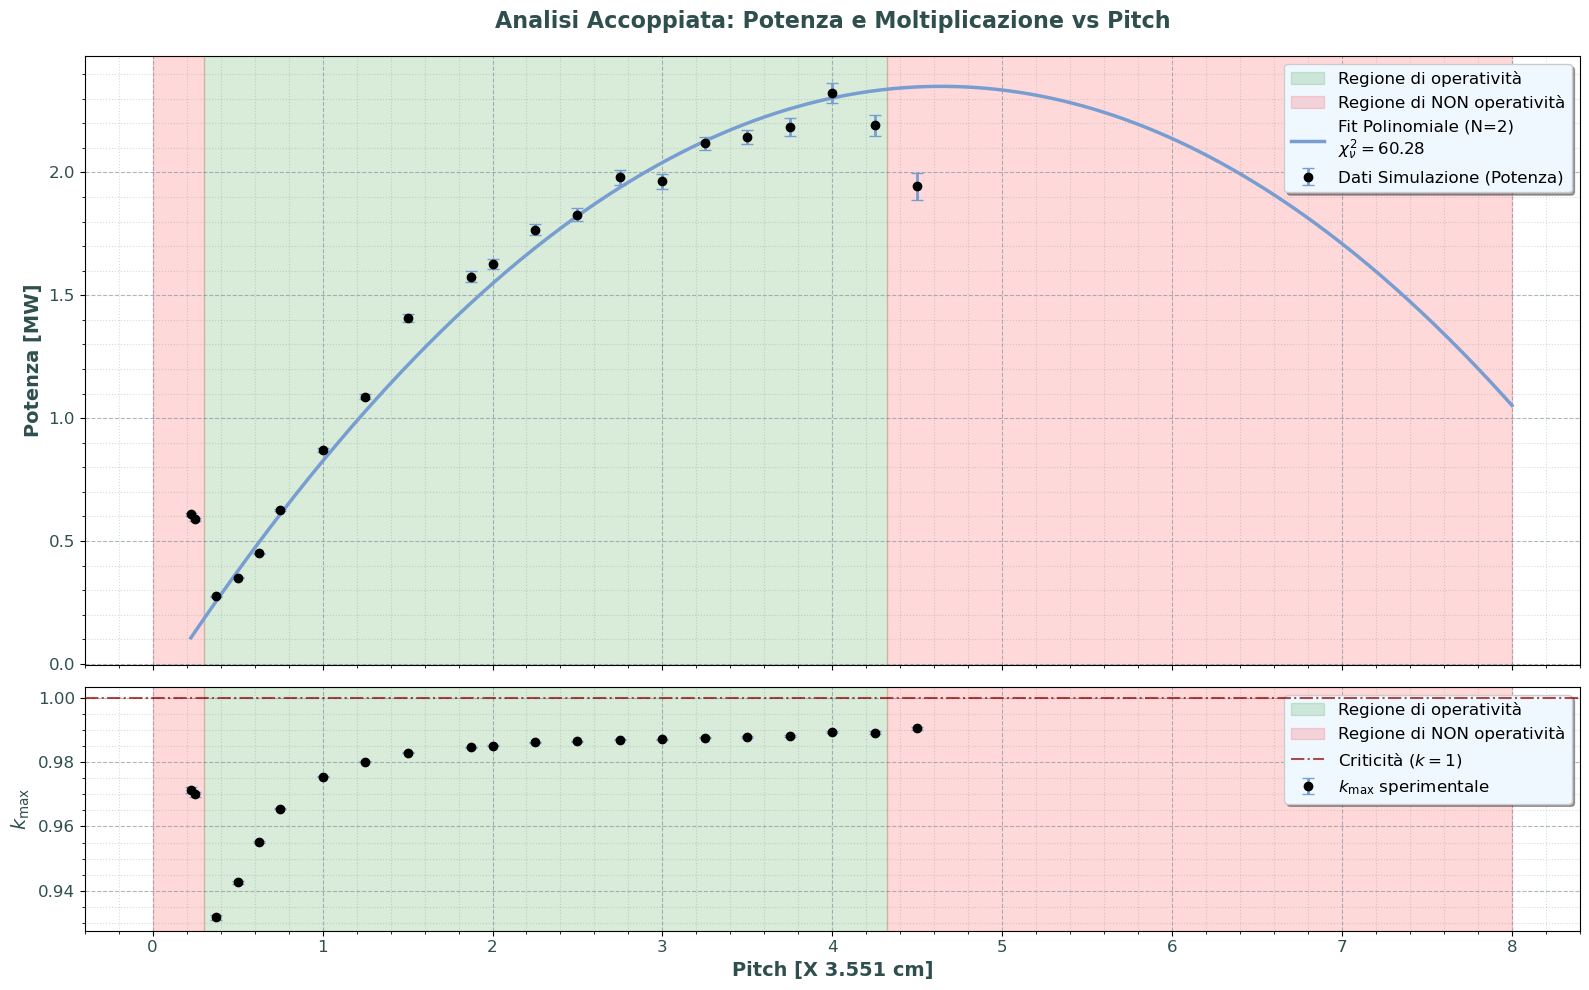

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

def plot_potenza_e_kmax(df_potenza, file_txt, N=2):
    """
    Esegue il fit polinomiale pesato sulla potenza e lo confronta con 
    l'andamento del k_max in due pad sovrapposti con zone di stabilità evidenziate.
    """
    if df_potenza.empty:
        print("Dataset potenza vuoto.")
        return
        
    df_potenza = df_potenza.copy().sort_values(by='Moltiplicatore')
    df_kmax = parse_result_final(file_txt).copy().sort_values(by='moltiplicatore')
    
    x_pow = df_potenza['Moltiplicatore'].values
    y_pow = df_potenza['Potenza_MW'].values
    err_pow = np.where(df_potenza['Errore_MW'].values == 0, 1e-10, df_potenza['Errore_MW'].values)
    
    # --- MASCHERA E CALCOLO FIT (SOLO 0.37 < x < 4.3) ---
    mask_fit = (x_pow > 0.37) & (x_pow < 4.3)
    x_pow_fit = x_pow[mask_fit]
    y_pow_fit = y_pow[mask_fit]
    err_pow_fit = err_pow[mask_fit]
    
    pesi = 1.0 / err_pow_fit
    coeff = np.polyfit(x_pow_fit, y_pow_fit, N, w=pesi)
    poly = np.poly1d(coeff)
    
    x_fit = np.linspace(x_pow.min(), 8, 500)
    y_fit = poly(x_fit)
    
    chi_quadro = np.sum(((y_pow_fit - poly(x_pow_fit)) / err_pow_fit)**2)
    dof = len(x_pow_fit) - (N + 1)
    chi_rid = chi_quadro / dof if dof > 0 else np.nan

    # --- CREAZIONE FIGURA ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, 
                                   gridspec_kw={'height_ratios': [2.5, 1]})
    
    # --- LOGICA SFONDI ---
    x_min_green = 0.3
    x_max_green = 4.32

    for ax in [ax1, ax2]:
        ax.axvspan(x_min_green, x_max_green, color='green', alpha=0.15, label='Regione di operatività')
        ax.axvspan(0, x_min_green, color='red', alpha=0.15, label='Regione di NON operatività')
        ax.axvspan(x_max_green, 8, color='red', alpha=0.15)
        
    # --- PAD SUPERIORE: POTENZA ---
    ax1.errorbar(x_pow, y_pow, yerr=err_pow, fmt='o', color='#000000', ecolor='#789DD1', 
                 elinewidth=2, capsize=4, zorder=5, label='Dati Simulazione (Potenza)')
    
    ax1.plot(x_fit, y_fit, zorder=4, color='#789DD1', linewidth=2.5, 
             label=rf'Fit Polinomiale (N={N})' + '\n' + rf'$\chi^2_\nu = {chi_rid:.2f}$')
    
    ax1.set_title('Analisi Accoppiata: Potenza e Moltiplicazione vs Pitch', 
                  fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
    ax1.set_ylabel('Potenza [MW]', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # --- PAD INFERIORE: K_MAX ---
    if not df_kmax.empty:
        # Corretti i nomi delle colonne
        ax2.errorbar(df_kmax['moltiplicatore'], df_kmax['k_max'], yerr=df_kmax['std_k_max'], 
                     fmt='o', color='#000000', ecolor='#789DD1', 
                     elinewidth=2, capsize=4, zorder=5, label='$k_{\max}$ sperimentale')
        ax2.axhline(y=1.0, color='#8B0000', linestyle='-.', linewidth=1.5, alpha=0.7, label='Criticità ($k=1$)', zorder=6)
        
    ax2.set_xlabel('Pitch [X 3.551 cm]', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax2.set_ylabel('$k_{\max}$', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # --- FORMATTAZIONE FINALE ---
    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='major', labelsize=12, labelcolor='#2F4F4F')
        ax.minorticks_on()
        ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899', zorder=2)
        ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899', zorder=2)
        
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='upper right', 
                  frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.05) 
    plt.savefig('potenza_kmax_vs_pitch_zone.png', dpi=300)
    plt.show()

plot_potenza_e_kmax(df_potenza, 'result_final.txt', N=2)

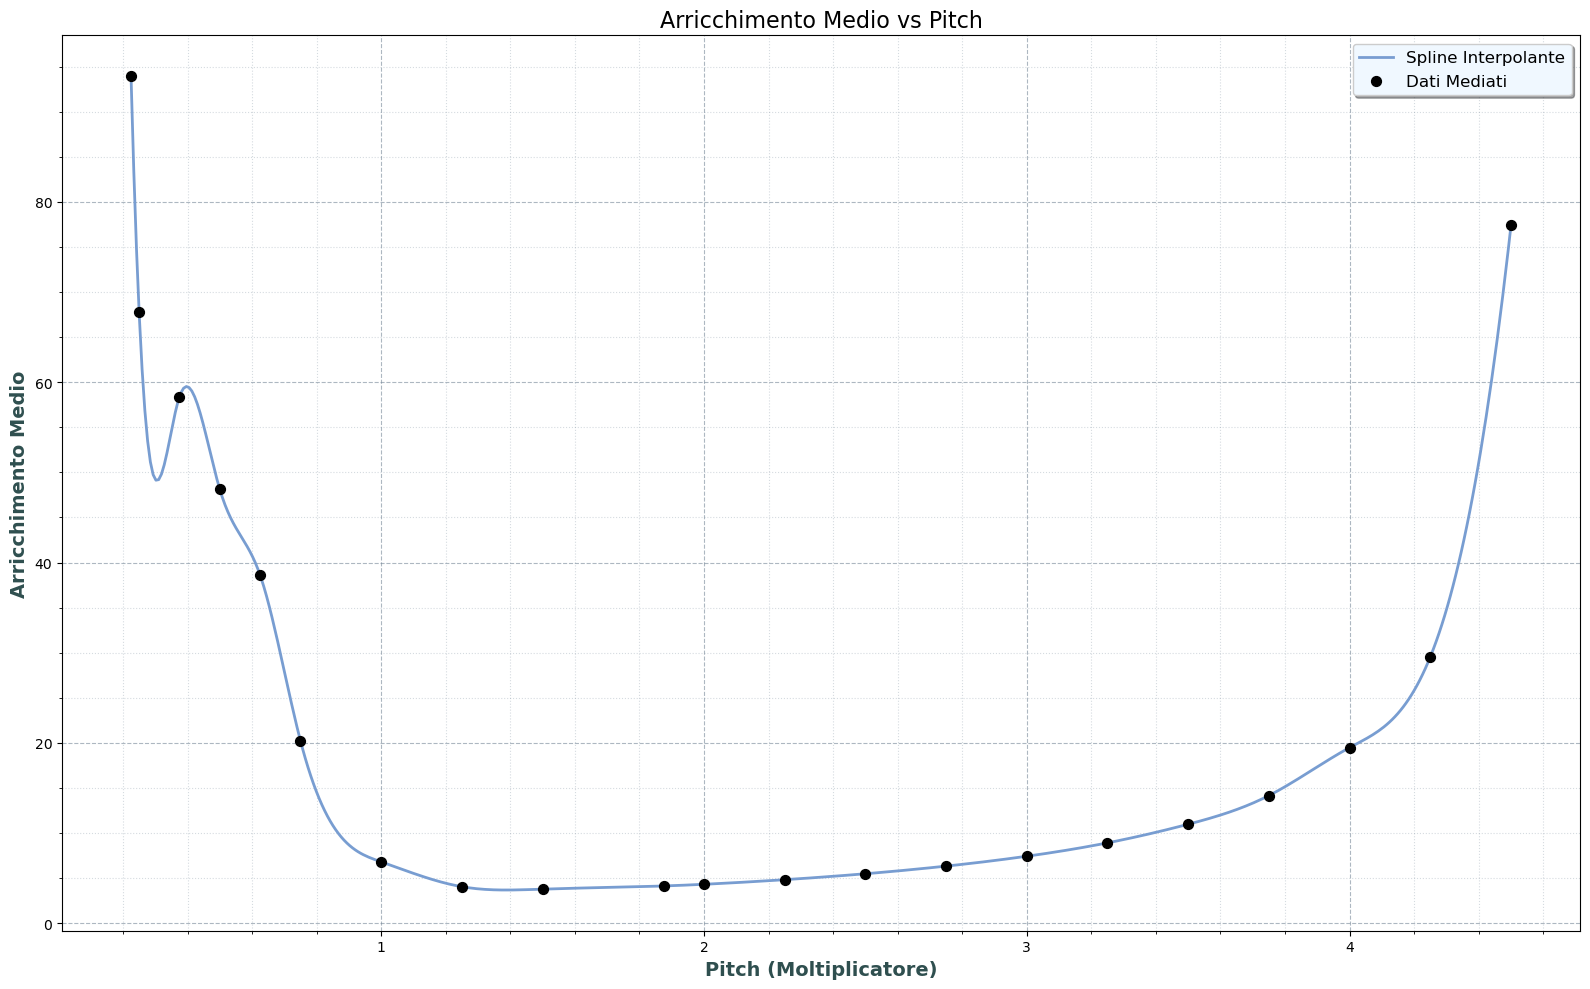

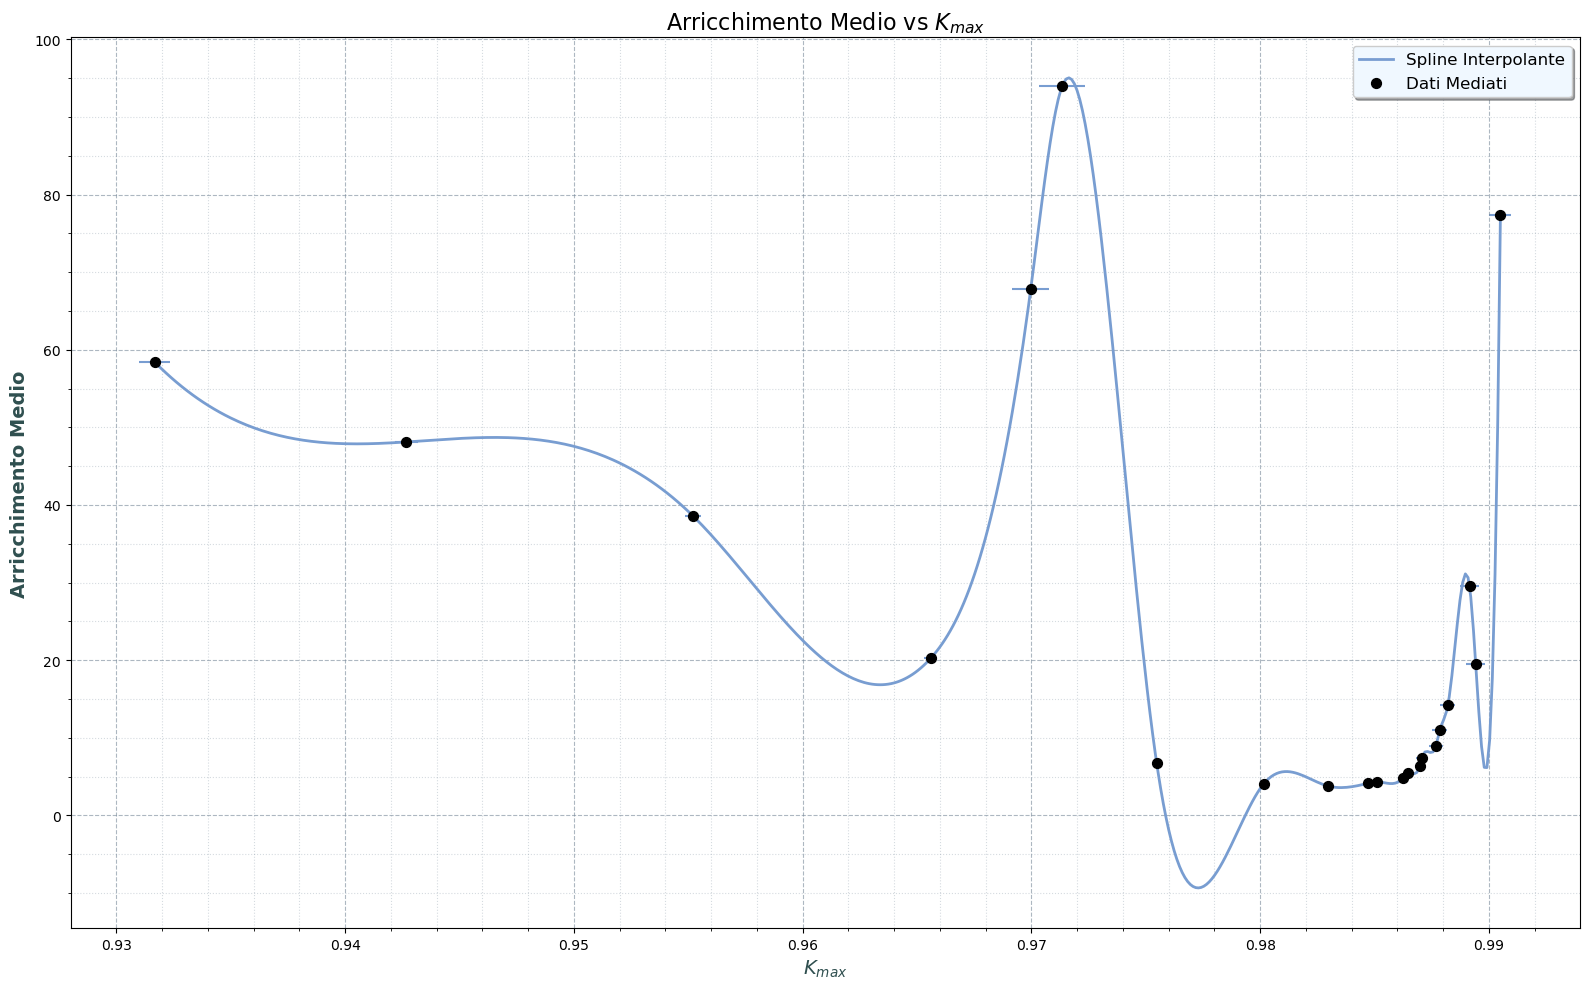

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

def parse_results(filepath):
    data = []
    current_row = []
    
    with open(filepath, 'r') as f:
        for line in f:
            if 'SIMULAZIONE' in line or 'PARAMETRI' in line or 'Pres' in line or 'INT' in line or '===' in line or '---' in line:
                continue

                
            parts = line.split()
            current_row.extend(parts)
            
            if len(current_row) >= 12:
                try:
                    pitch = float(current_row[1])
                    arr_int = float(current_row[3])
                    arr_ext = float(current_row[4])
                    k_max = float(current_row[7])
                    std_k_max = float(current_row[8])
                    data.append((pitch, arr_int, arr_ext, k_max, std_k_max))
                except ValueError:
                    pass
                current_row = current_row[12:]
                
    data = np.array(data)
    return data[:, 0], data[:, 1], data[:, 2], data[:, 3], data[:, 4]

def calculate_avg_enrichment(arr_ints, arr_exts):
    n_rings = np.arange(1, 12)
    rods_per_ring = 6 * (n_rings + 1)
    tot_rods = np.sum(rods_per_ring)
    
    avg_enrichments = []
    for a_int, a_ext in zip(arr_ints, arr_exts):
        arr_n = a_int + (a_ext - a_int) / 10.0 * (n_rings - 1)
        tot_arr = np.sum(arr_n * rods_per_ring)
        avg_enrichments.append(tot_arr / tot_rods)
        
    return np.array(avg_enrichments)

def create_spline_plot(x, y, xlabel, ylabel, title, xerr=None):
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # Risoluzione duplicati: media delle y per ogni x unica
    x_unique = np.unique(x)
    y_unique = np.array([np.mean(y[x == val]) for val in x_unique])
    
    if xerr is not None:
        xerr_unique = np.array([np.mean(xerr[x == val]) for val in x_unique])
    else:
        xerr_unique = None
        
    # Generazione Spline sui dati univoci mediati
    x_smooth = np.linspace(x_unique.min(), x_unique.max(), 500)
    
    # Se ci sono meno di 4 punti univoci, la spline cubica (k=3) fallisce, riduciamo il grado
    k_degree = 3 if len(x_unique) >= 4 else len(x_unique) - 1
    
    if k_degree > 0:
        spline = make_interp_spline(x_unique, y_unique, k=k_degree)
        y_smooth = spline(x_smooth)
        ax.plot(x_smooth, y_smooth, color='#789DD1', linewidth=2, label='Spline Interpolante', zorder=2)
    else:
        # Fallback se c'è un solo punto
        ax.plot(x_unique, y_unique, color='#789DD1', linewidth=2, label='Dati', zorder=2)

    # Error bars (visibili solo per k_max se presente)
    if xerr_unique is not None:
        ax.errorbar(x_unique, y_unique, xerr=xerr_unique, fmt='none', ecolor='#789DD1', zorder=1)
        
    # Plot Scatter sui punti mediati
    ax.scatter(x_unique, y_unique, color='#000000', s=50, label='Dati Mediati', zorder=3)
    
    # Formattazione Testo e Griglia (da tue impostazioni)
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_title(title, fontsize=16)
    
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.minorticks_on()
    
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
    
    fig.tight_layout()
    plt.show() # Sostituito savefig per mostrare nel notebook

if __name__ == '__main__':
    filepath = 'result_final.txt'
    pitches, arr_ints, arr_exts, k_maxs, std_k_maxs = parse_results(filepath)
    avg_arr = calculate_avg_enrichment(arr_ints, arr_exts)
    
    # Arricchimento Medio vs Pitch
    create_spline_plot(pitches, avg_arr, 
                       'Pitch (Moltiplicatore)', 'Arricchimento Medio', 
                       'Arricchimento Medio vs Pitch')
    
    # Arricchimento Medio vs K_max
    create_spline_plot(k_maxs, avg_arr, 
                       '$K_{max}$', 'Arricchimento Medio', 
                       'Arricchimento Medio vs $K_{max}$', xerr=std_k_maxs)

il plot k_max VS pitch lo abbiamo già 

noto troppe omiglianze per essere una coincidenza

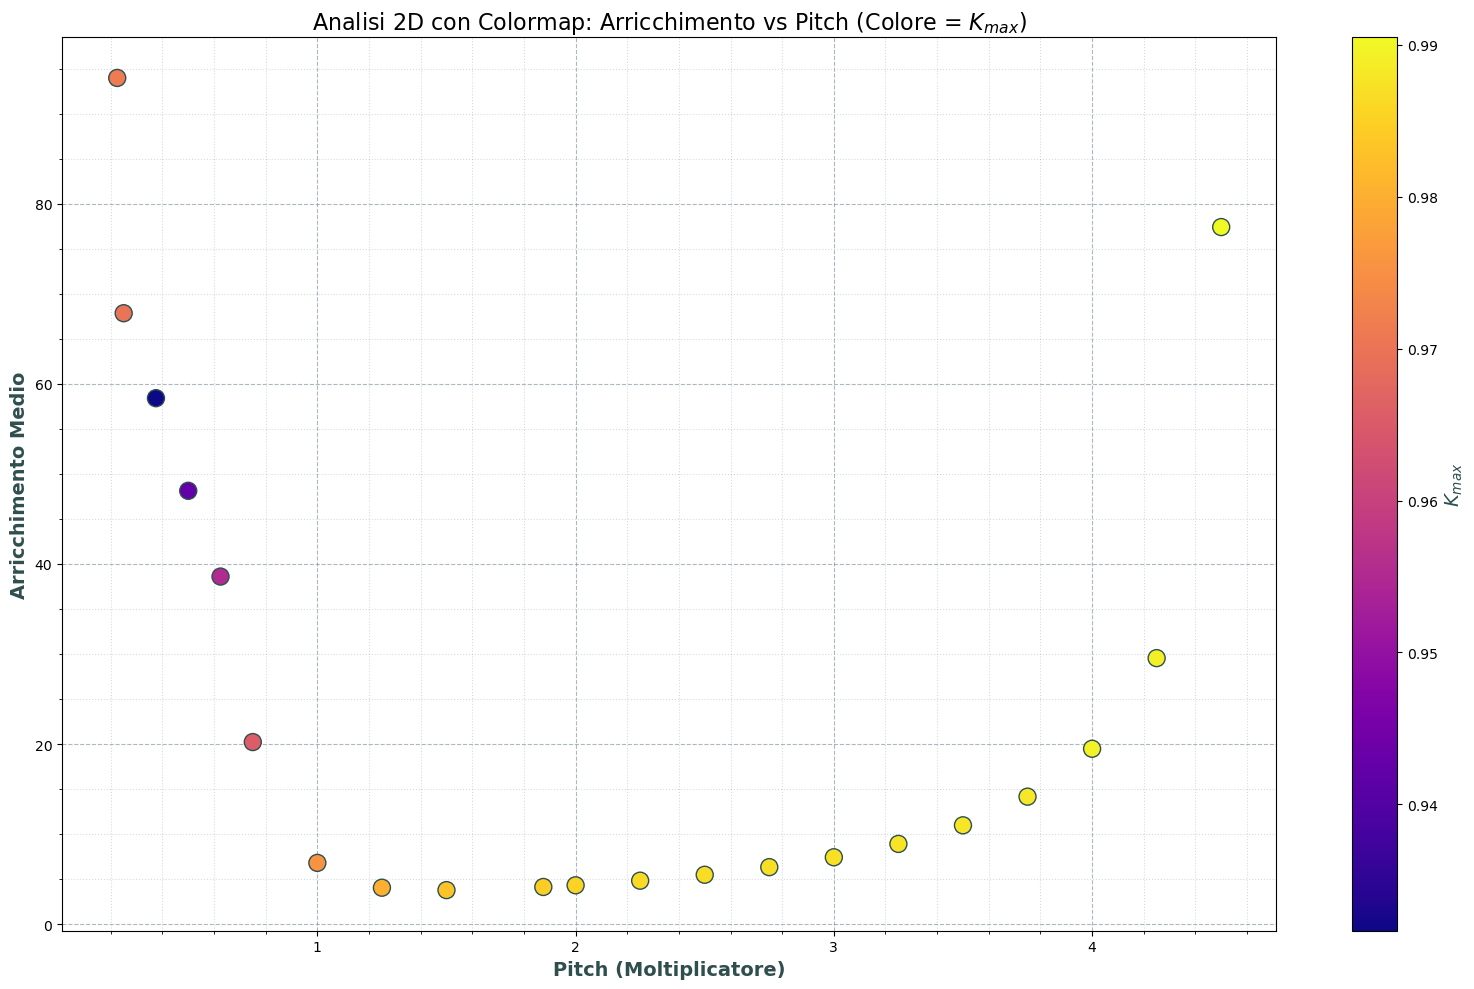

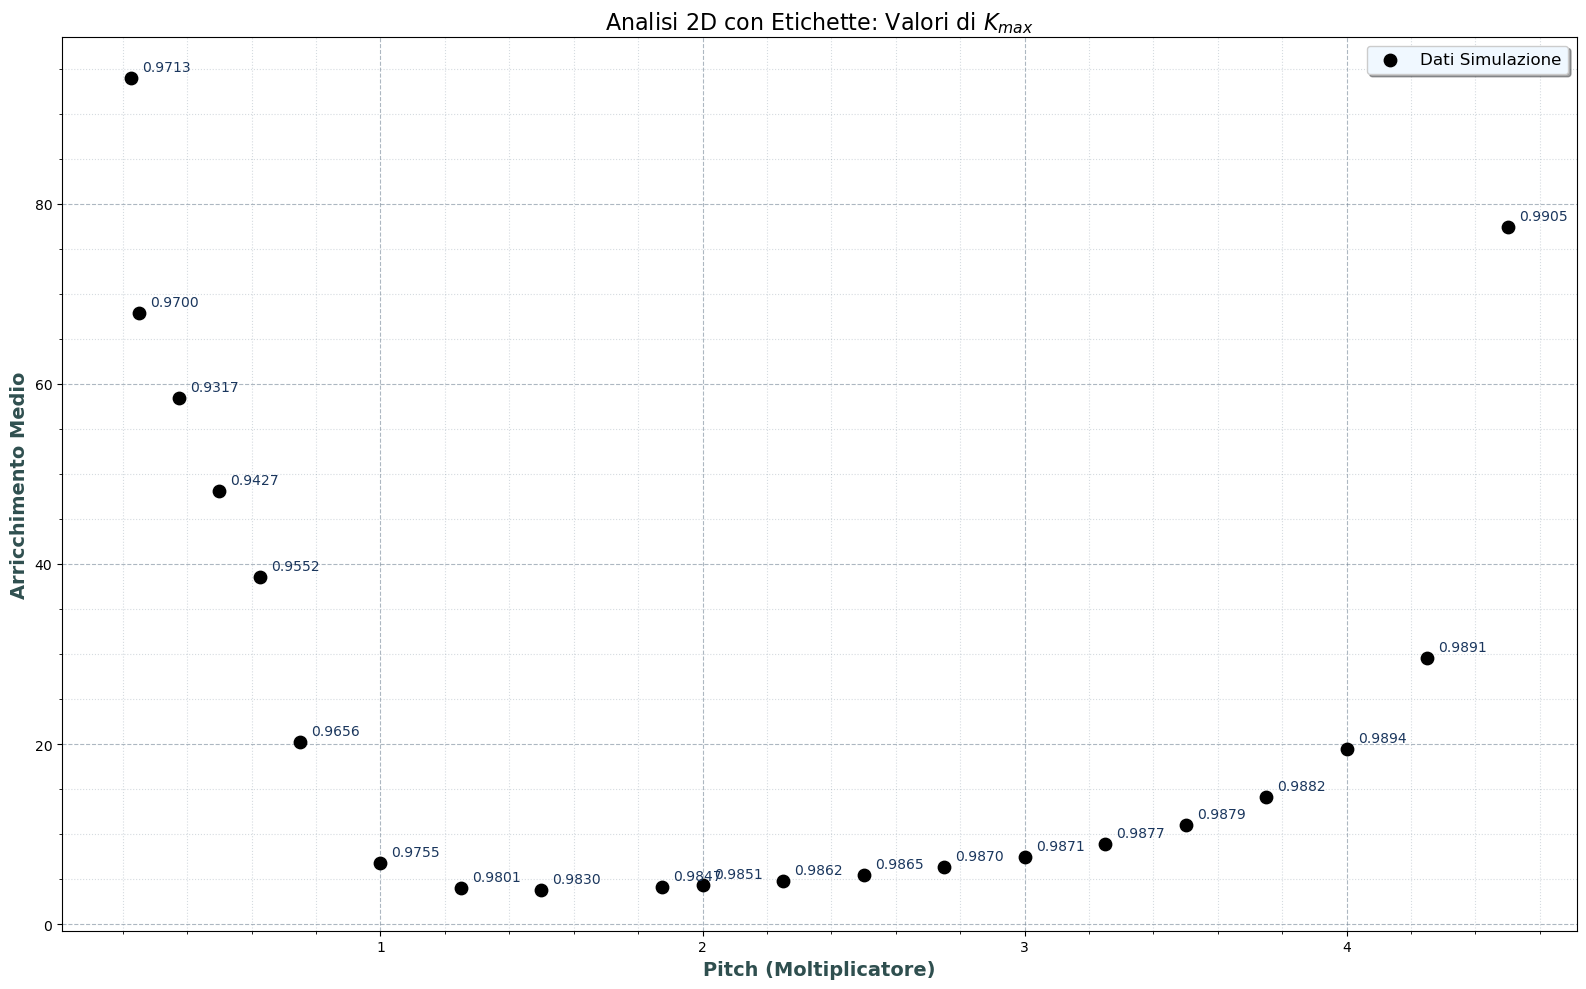

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def parse_results(filepath):
    data = []
    current_row = []
    with open(filepath, 'r') as f:
        for line in f:
            if any(kw in line for kw in ['SIMULAZIONE', 'PARAMETRI', 'Pres', 'INT', '===', '---']):
                continue
            
            parts = line.split()
            current_row.extend(parts)
            if len(current_row) >= 12:
                try:
                    pitch = float(current_row[1])
                    arr_int = float(current_row[3])
                    arr_ext = float(current_row[4])
                    k_max = float(current_row[7])
                    std_k_max = float(current_row[8])
                    data.append((pitch, arr_int, arr_ext, k_max, std_k_max))
                except ValueError:
                    pass
                current_row = current_row[12:]
    data = np.array(data)
    return data[:, 0], data[:, 1], data[:, 2], data[:, 3], data[:, 4]

def calculate_avg_enrichment(arr_ints, arr_exts):
    n_rings = np.arange(1, 12)
    rods_per_ring = 6 * (n_rings + 1)
    tot_rods = np.sum(rods_per_ring)
    avg_enrichments = []
    for a_int, a_ext in zip(arr_ints, arr_exts):
        arr_n = a_int + (a_ext - a_int) / 10.0 * (n_rings - 1)
        tot_arr = np.sum(arr_n * rods_per_ring)
        avg_enrichments.append(tot_arr / tot_rods)
    return np.array(avg_enrichments)

def apply_custom_style(ax, xlabel, ylabel, title):
    """Applica lo stile base unificato"""
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_title(title, fontsize=16)
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.minorticks_on()

def plot_2d_colormap(pitch, avg_arr, k_max):
    """Opzione 1: Scatter 2D con K_max mappato sul colore (Toni freddi)"""
    fig, ax = plt.subplots(figsize=(16, 10))
    # Utilizzo della colormap PuBu (Purple-Blue) adatta alla palette Summer Cool
    sc = ax.scatter(pitch, avg_arr, c=k_max, cmap='plasma', s=150, edgecolor='#2F4F4F', zorder=3)
    
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('$K_{max}$', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    apply_custom_style(ax, 'Pitch (Moltiplicatore)', 'Arricchimento Medio', 'Analisi 2D con Colormap: Arricchimento vs Pitch (Colore = $K_{max}$)')
    fig.tight_layout()
    plt.show()

def plot_2d_annotated(pitch, avg_arr, k_max):
    """Opzione 2: Scatter 2D con label testuali per K_max vicino ai punti"""
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.scatter(pitch, avg_arr, color='#000000', s=80, zorder=3, label='Dati Simulazione')
    
    # Annotazione dei punti
    for p, a, k in zip(pitch, avg_arr, k_max):
        ax.annotate(f'{k:.4f}', (p, a), xytext=(8, 5), textcoords='offset points', 
                    fontsize=10, color='#1A365D') # Navy blue text
                    
    apply_custom_style(ax, 'Pitch (Moltiplicatore)', 'Arricchimento Medio', 'Analisi 2D con Etichette: Valori di $K_{max}$')
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
    fig.tight_layout()
    plt.show()

if __name__ == '__main__':
    filepath = 'result_final.txt'
    pitches, arr_ints, arr_exts, k_maxs, std_k_maxs = parse_results(filepath)
    avg_arr = calculate_avg_enrichment(arr_ints, arr_exts)
    
    # Esecuzione in serie delle 4 opzioni per valutazione
    plot_2d_colormap(pitches, avg_arr, k_maxs)
    plot_2d_annotated(pitches, avg_arr, k_maxs)
   

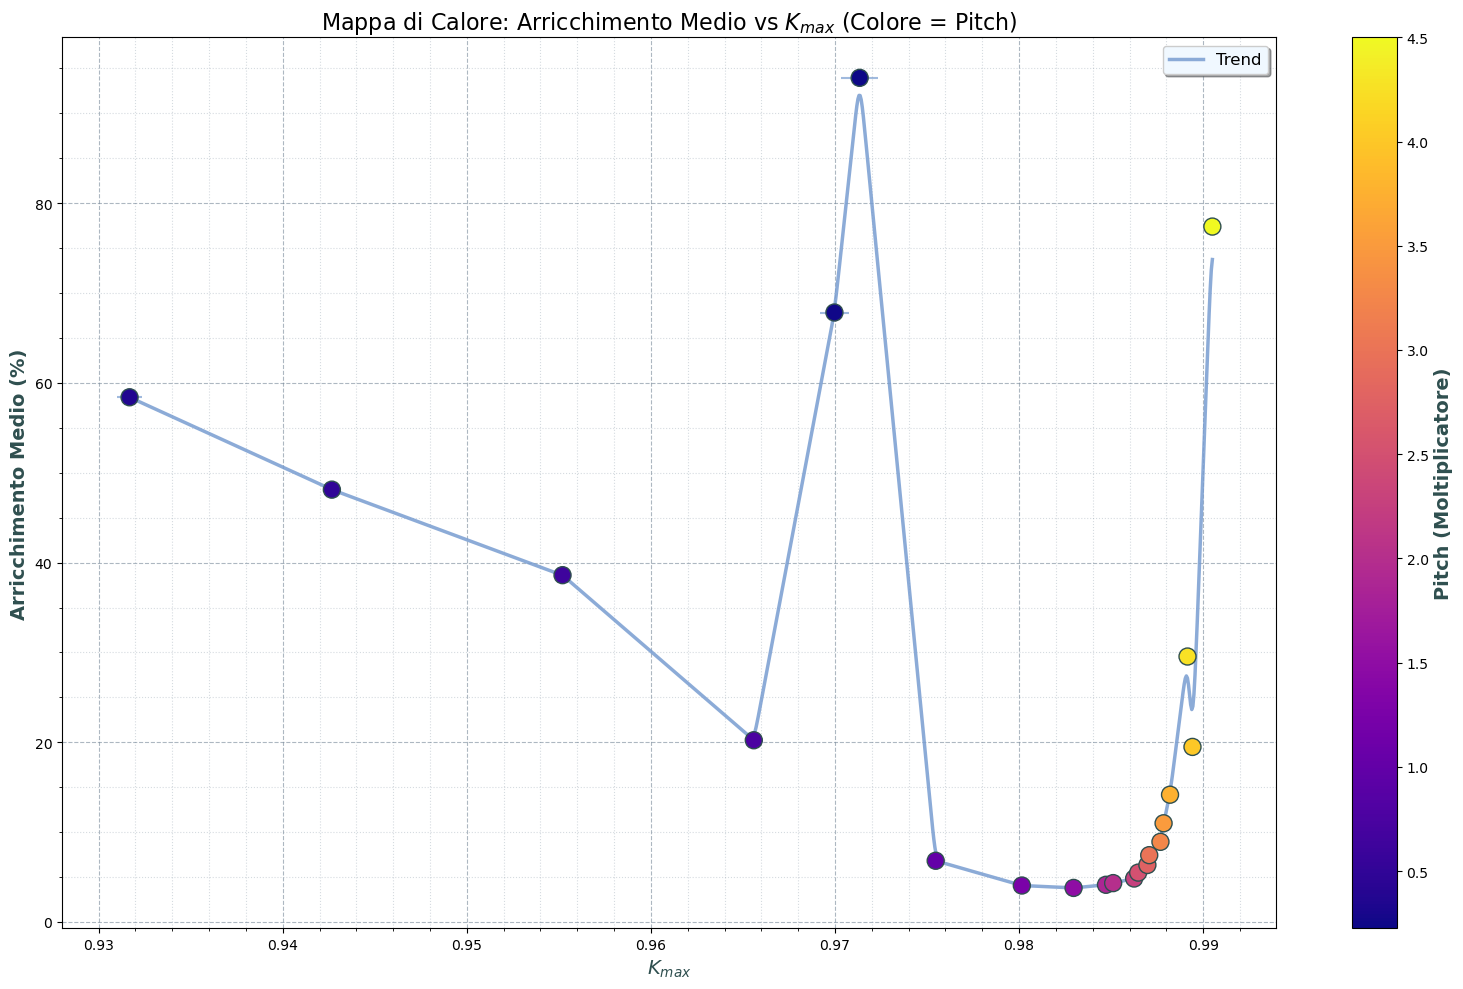

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def parse_results(filepath):
    data = []
    current_row = []
    with open(filepath, 'r') as f:
        for line in f:
            if any(kw in line for kw in ['SIMULAZIONE', 'PARAMETRI', 'Pres', 'INT', '===', '---']):
                continue
            
            parts = line.split()
            current_row.extend(parts)
            
            if len(current_row) >= 12:
                try:
                    pitch = float(current_row[1])
                    arr_int = float(current_row[3])
                    arr_ext = float(current_row[4])
                    k_max = float(current_row[7])
                    std_k_max = float(current_row[8])
                    data.append((pitch, arr_int, arr_ext, k_max, std_k_max))
                except ValueError:
                    pass
                current_row = current_row[12:]
                
    data = np.array(data)
    return data[:, 0], data[:, 1], data[:, 2], data[:, 3], data[:, 4]

def calculate_avg_enrichment(arr_ints, arr_exts):
    n_rings = np.arange(1, 12)
    rods_per_ring = 6 * (n_rings + 1)
    tot_rods = np.sum(rods_per_ring)
    
    avg_enrichments = []
    for a_int, a_ext in zip(arr_ints, arr_exts):
        arr_n = a_int + (a_ext - a_int) / 10.0 * (n_rings - 1)
        tot_arr = np.sum(arr_n * rods_per_ring)
        avg_enrichments.append(tot_arr / tot_rods)
        
    return np.array(avg_enrichments)

def plot_kmax_vs_arr_heatmap(pitch, avg_arr, k_max, std_k_max):
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # 1. Media dell'arricchimento (y) per ogni valore univoco di K_max (x)
    x_unq, unq_idx = np.unique(k_max, return_inverse=True)
    y_unq = np.bincount(unq_idx, weights=avg_arr) / np.bincount(unq_idx)
    
    # 2. Interpolazione lineare densa
    x_dense = np.linspace(x_unq.min(), x_unq.max(), 1000)
    y_linear = np.interp(x_dense, x_unq, y_unq)
    
    # 3. Ammorbidimento tramite Filtro Gaussiano 1D
    y_soft = gaussian_filter1d(y_linear, sigma=2)
    
    # Plot della curva ammorbidita
    ax.plot(x_dense, y_soft, color='#789DD1', linewidth=2.5, alpha=0.85, zorder=2, label='Trend')
    
    # Barre di errore (ora associate all'asse x per K_max)
    ax.errorbar(k_max, avg_arr, xerr=std_k_max, fmt='none', ecolor='#789DD1', zorder=1, alpha=0.7)
    
    # Scatter plot 
    sc = ax.scatter(k_max, avg_arr, c=pitch, cmap='plasma', s=150, edgecolor='#2F4F4F', zorder=3)
    
    # Configurazione Colorbar
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Pitch (Moltiplicatore)', fontsize=14, fontweight='bold', color='#2F4F4F')
    
    # Formattazione Testo e Assi inversi
    ax.set_xlabel('$K_{max}$', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_ylabel('Arricchimento Medio (%)', fontsize=14, fontweight='bold', color='#2F4F4F')
    ax.set_title('Mappa di Calore: Arricchimento Medio vs $K_{max}$ (Colore = Pitch)', fontsize=16)
    
    # Griglia Custom
    ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
    ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')
    ax.minorticks_on()
    
    ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')
    
    fig.tight_layout()
    plt.show()

if __name__ == '__main__':
    filepath = 'result_final.txt'
    pitches, arr_ints, arr_exts, k_maxs, std_k_maxs = parse_results(filepath)
    avg_arr = calculate_avg_enrichment(arr_ints, arr_exts)
    
    plot_kmax_vs_arr_heatmap(pitches, avg_arr, k_maxs, std_k_maxs)